<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_Fourier_Neural_Operator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fourier Neural Operator

A Fourier Neural Operator (FNO) is a novel deep learning architecture designed to learn mappings between infinite-dimensional function spaces. Unlike traditional neural networks that learn mappings between finite-dimensional Euclidean spaces, FNOs can directly learn the solution operator for partial differential equations (PDEs), making them highly effective for tasks involving complex physical systems.

### Core Idea
The fundamental idea behind FNOs is to perform a significant portion of the neural network's computations in the **Fourier domain**. This allows the network to capture global dependencies and long-range interactions more efficiently than convolutional neural networks (CNNs) that operate in the spatial domain and capture local features.

### How it Works (1D Case)
Let's break down the FNO architecture, focusing on a 1D example for simplicity (e.g., predicting the evolution of a 1D field over time):

1.  **Lift to Higher Dimension (Input Embedding):**
    *   The input function `u(x)` (e.g., an initial condition or a snapshot of a physical field) is first lifted to a higher-dimensional representation `v0(x)` using a shallow, fully-connected neural network (e.g., an `nn.Linear` layer).
    *   `v0(x) = P(u(x))` where `P` is the lifting operator.
    *   This transforms the input `(batch_size, grid_points, input_channels)` to `(batch_size, grid_points, width)`, where `width` is the hidden dimension of the FNO.

2.  **Iterative Fourier Layers:**
    *   The core of the FNO consists of several stacked **Fourier layers**. Each layer performs a transformation `v_t+1 = W(v_t) + (R(v_t) ∘ σ)`. Let's break this down:

    a.  **Fourier Transformation (Global Mixing):**
        *   The current representation `v_t(x)` is transformed into the Fourier domain using the Fast Fourier Transform (FFT).
        *   `v_t_ft = FFT(v_t(x))`
        *   In the Fourier domain, multiplication corresponds to convolution in the spatial domain. FNOs leverage this by applying a linear transformation (a learnable weight matrix) to the lower Fourier modes.
        *   `R(v_t_ft)`: This involves truncating the high-frequency modes (a low-pass filter) and then applying a learned linear operator (complex-valued weights) to the remaining modes. This directly models global interactions.
        *   `R(v_t) = InverseFFT(Truncate(R(v_t_ft)))`: The result is transformed back to the spatial domain using Inverse FFT.

    b.  **Linear Transformation (Local Mixing):**
        *   Simultaneously, a local linear transformation `W(v_t)` is applied in the spatial domain using a simple fully-connected layer or a 1x1 convolution (which acts independently at each grid point across channels).
        *   This captures local interactions that might not be efficiently modeled by the Fourier modes, or complements the global interactions.

    c.  **Combination and Activation:**
        *   The outputs from the Fourier transformation `R(v_t)` and the local linear transformation `W(v_t)` are summed up.
        *   `v_t+1(x) = σ(W(v_t(x)) + R(v_t(x)))` where `σ` is an activation function (e.g., GELU, ReLU).
        *   This sum forms a residual connection, aiding in stable training.

3.  **Project Down (Output Embedding):**
    *   After several Fourier layers, the final high-dimensional representation `v_L(x)` is projected back to the desired output dimension (e.g., the predicted future state `u_pred(x)`) using another shallow, fully-connected neural network.
    *   `u_pred(x) = Q(v_L(x))` where `Q` is the projection operator.

### Key Advantages of FNOs:

*   **Resolution Invariance:** FNOs learn the operator directly, not just a specific discretization. This means a trained FNO can be applied to different grid resolutions without retraining.
*   **Computational Efficiency:** By performing operations in the Fourier domain, FNOs can capture long-range dependencies with much lower computational cost (O(N log N) for FFT) compared to large CNNs or attention mechanisms (which can be O(N^2)).
*   **Strong Performance on PDEs:** They have shown state-of-the-art results in solving various types of PDEs, including Burgers' equation, Navier-Stokes equation, and Darcy flow.
*   **Generalization:** They exhibit good generalization capabilities to unseen initial conditions and parameters of the underlying physical system.

### Analogy
Think of it like this: a regular CNN might learn to recognize local patterns in an image (like edges or corners), but to understand the global structure (like the entire object), it needs many layers. An FNO, by operating in the Fourier domain, can immediately grasp global frequency components (like the overall shape or periodicity) and combine them with local spatial features, allowing for a more holistic and efficient understanding of functions and physical phenomena.

### Application in this Notebook:
In this notebook, the FNO is used for 1D time series prediction, specifically for data that mimics the behavior of Burger's equation. The `input_steps` (e.g., 10 previous time steps) are treated as `input_channels` and the FNO predicts the `prediction_steps` (e.g., 20 future time steps) as `output_channels` across the spatial grid.

In [ ]:
!pip install fourier-neural-operator -q
!pip install torch torchvision torchaudio -q

  Preparing metadata (setup.py) ... done


In [ ]:


# Cell 2: Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:

# Cell 3: Fixed 1D Fourier Neural Operator implementation
class SpectralConv1d(nn.Module):
    """1D Fourier spectral convolution layer - Fixed version"""
    def __init__(self, in_channels, out_channels, modes):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes  # Number of Fourier modes to keep

        # Scale for initialization
        self.scale = 1.0 / (in_channels * out_channels)

        # Real and imaginary parts for Fourier weights
        self.weights_real = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes)
        )
        self.weights_imag = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes)
        )

    def forward(self, x):
        """Forward pass with FFT
        Args:
            x: Input tensor of shape (batch, channels, grid_points)
        Returns:
            Output tensor of shape (batch, channels, grid_points)
        """
        batch_size = x.shape[0]

        # Compute Fourier transform (rfft for real input)
        x_ft = torch.fft.rfft(x)

        # Prepare output tensor
        out_ft = torch.zeros(batch_size, self.out_channels, x.size(-1)//2 + 1,
                            dtype=torch.cfloat, device=x.device)

        # Apply Fourier mode convolution using complex weights
        # out_ft[b, o, k] = sum_i x_ft[b, i, k] * (w_real + i*w_imag)
        for i in range(self.in_channels):
            for o in range(self.out_channels):
                # Complex multiplication
                real_part = x_ft[:, i, :self.modes].real * self.weights_real[i, o] - \
                           x_ft[:, i, :self.modes].imag * self.weights_imag[i, o]
                imag_part = x_ft[:, i, :self.modes].real * self.weights_imag[i, o] + \
                           x_ft[:, i, :self.modes].imag * self.weights_real[i, o]
                out_ft[:, o, :self.modes] += torch.complex(real_part, imag_part)

        # Inverse Fourier transform
        x_out = torch.fft.irfft(out_ft, n=x.size(-1))

        return x_out

class FNO1d(nn.Module):
    """Fourier Neural Operator for 1D problems"""
    def __init__(self, modes, width, input_channels, output_channels, n_layers=4):
        super(FNO1d, self).__init__()
        self.modes = modes
        self.width = width
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.n_layers = n_layers

        # Input projection layer
        self.fc0 = nn.Linear(input_channels, width)

        # Fourier layers
        self.spectral_layers = nn.ModuleList([
            SpectralConv1d(width, width, modes) for _ in range(n_layers)
        ])

        # Local linear layers (W in the paper)
        self.w_layers = nn.ModuleList([
            nn.Conv1d(width, width, 1) for _ in range(n_layers)
        ])

        # Output projection layers
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, output_channels)

        # Activation function
        self.activation = F.gelu

    def forward(self, x):
        """Forward pass
        Args:
            x: Input tensor of shape (batch_size, grid_points, input_channels)
        Returns:
            Output tensor of shape (batch_size, grid_points, output_channels)
        """
        batch_size, grid_size, _ = x.shape

        # Lift input to higher dimension
        x = self.fc0(x)  # (batch, grid, width)
        x = x.permute(0, 2, 1)  # (batch, width, grid)

        # Apply Fourier layers with residual connections
        for k in range(self.n_layers):
            # Spectral path (global convolution in Fourier space)
            x_spectral = self.spectral_layers[k](x)

            # Local path (pointwise convolution)
            x_local = self.w_layers[k](x)

            # Combine and apply activation
            x = self.activation(x_spectral + x_local)

        # Project back to output space
        x = x.permute(0, 2, 1)  # (batch, grid, width)
        x = self.activation(self.fc1(x))
        x = self.fc2(x)

        return x


In [ ]:

# Cell 4: Generate synthetic 1D time series data
def generate_burgers_data(n_samples=1000, grid_size=256):
    """Generate synthetic data similar to Burgers' equation behavior"""
    x = np.linspace(0, 1, grid_size)

    data = []
    for _ in range(n_samples):
        # Random initial condition parameters
        amplitude = np.random.uniform(0.5, 2.0)
        frequency1 = np.random.uniform(1, 5)
        frequency2 = np.random.uniform(6, 12)
        phase = np.random.uniform(0, 2*np.pi)

        # Generate complex wave pattern
        u = amplitude * (0.7 * np.sin(frequency1 * x + phase) +
                        0.3 * np.sin(frequency2 * x + 2*phase))

        # Add nonlinear interaction (Burgers-like shock)
        u = u * (1 + 0.2 * u)

        # Add small noise
        u = u + 0.02 * np.random.randn(grid_size)

        # Normalize
        u = (u - u.mean()) / (u.std() + 1e-8)

        data.append(u)

    return np.array(data)

def generate_temporal_evolution(initial_data, n_time_steps=100, dt=0.01, nu=0.01):
    """Generate temporal evolution using Burgers' equation dynamics"""
    n_samples, grid_size = initial_data.shape
    data = np.zeros((n_samples, n_time_steps, grid_size))

    for i in range(n_samples):
        u = initial_data[i].copy()
        data[i, 0] = u

        for t in range(1, n_time_steps):
            # Simple Burgers' equation update: u_t + u*u_x = nu*u_xx
            u_x = np.gradient(u)
            u_xx = np.gradient(u_x)

            # Time evolution
            u = u - dt * (u * u_x - nu * u_xx)
            data[i, t] = u

            # Periodic boundary conditions (implicitly via gradient)
            u[0] = u[-2]
            u[-1] = u[1]

    return data

In [ ]:


# Cell 5: Prepare dataset for time series prediction
def prepare_timeseries_dataset(data, input_steps=10, prediction_steps=20):
    """Prepare dataset for time series prediction using FNO"""
    n_samples, n_timesteps, n_grid = data.shape

    inputs = []
    targets = []

    # Use sliding window approach
    stride = max(1, input_steps // 2)

    for i in range(n_samples):
        for t in range(0, n_timesteps - input_steps - prediction_steps, stride):
            # Input: input_steps time steps (as channels)
            input_seq = data[i, t:t+input_steps, :].T  # (grid, input_steps)
            # Target: next prediction_steps time steps
            target_seq = data[i, t+input_steps:t+input_steps+prediction_steps, :].T

            inputs.append(input_seq)
            targets.append(target_seq)

    return np.array(inputs), np.array(targets)

In [ ]:


# Cell 6: Generate and prepare data
print("Generating synthetic data...")
n_samples = 500
grid_size = 128
n_time_steps = 80

# Generate initial conditions
initial_data = generate_burgers_data(n_samples, grid_size)
print(f"Initial conditions shape: {initial_data.shape}")

# Generate temporal evolution
print("Generating temporal evolution...")
data = generate_temporal_evolution(initial_data, n_time_steps, dt=0.01, nu=0.005)
print(f"Full data shape: {data.shape}")

# Prepare time series data
input_steps = 10
prediction_steps = 20
print(f"Creating sequences: {input_steps} input steps -> {prediction_steps} prediction steps")

X, y = prepare_timeseries_dataset(data, input_steps, prediction_steps)
print(f"Input shape: {X.shape}")  # (samples, grid_points, input_steps)
print(f"Target shape: {y.shape}")  # (samples, grid_points, prediction_steps)

# Split into train/val/test
n_samples = X.shape[0]
train_idx = int(0.7 * n_samples)
val_idx = int(0.85 * n_samples)

X_train = torch.FloatTensor(X[:train_idx]).to(device)
y_train = torch.FloatTensor(y[:train_idx]).to(device)
X_val = torch.FloatTensor(X[train_idx:val_idx]).to(device)
y_val = torch.FloatTensor(y[train_idx:val_idx]).to(device)
X_test = torch.FloatTensor(X[val_idx:]).to(device)
y_test = torch.FloatTensor(y[val_idx:]).to(device)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Create dataloaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

Generating synthetic data...
Initial conditions shape: (500, 128)
Generating temporal evolution...
Full data shape: (500, 80, 128)
Creating sequences: 10 input steps -> 20 prediction steps
Input shape: (5000, 128, 10)
Target shape: (5000, 128, 20)
Train: torch.Size([3500, 128, 10]), Val: torch.Size([750, 128, 10]), Test: torch.Size([750, 128, 10])


In [ ]:


# Cell 7: Initialize FNO model
# FNO parameters
modes = 8  # Number of Fourier modes to keep
width = 16  # Width of hidden layers
n_layers = 4  # Number of Fourier layers

input_channels = input_steps
output_channels = prediction_steps

model = FNO1d(modes=modes, width=width,
             input_channels=input_channels,
             output_channels=output_channels,
             n_layers=n_layers).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Cell 8: Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

# Cell 9: Training loop
num_epochs = 15
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_fno_model.pth')

    # Update learning rate
    scheduler.step(val_loss)

    # Progress tracking
    if (epoch + 1) % 1 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.6f}, "
              f"Val Loss: {val_loss:.6f}, "
              f"LR: {current_lr:.6f}")

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

# Load best model
model.load_state_dict(torch.load('best_fno_model.pth'))


Total parameters: 22,404
Trainable parameters: 22,404
Starting training...
Epoch [1/15], Train Loss: 4.841058, Val Loss: 0.272177, LR: 0.010000
Epoch [2/15], Train Loss: 4.545455, Val Loss: 0.276400, LR: 0.010000
Epoch [3/15], Train Loss: 4.442789, Val Loss: 0.217984, LR: 0.010000
Epoch [4/15], Train Loss: 4.371175, Val Loss: 0.190855, LR: 0.010000
Epoch [5/15], Train Loss: 3.860993, Val Loss: 0.234938, LR: 0.010000
Epoch [6/15], Train Loss: 4.315017, Val Loss: 0.117664, LR: 0.010000
Epoch [7/15], Train Loss: 3.901089, Val Loss: 0.249427, LR: 0.010000
Epoch [8/15], Train Loss: 3.698602, Val Loss: 0.218192, LR: 0.010000
Epoch [9/15], Train Loss: 4.282051, Val Loss: 0.148033, LR: 0.010000
Epoch [10/15], Train Loss: 4.339997, Val Loss: 0.093230, LR: 0.010000
Epoch [11/15], Train Loss: 3.528955, Val Loss: 0.035047, LR: 0.010000
Epoch [12/15], Train Loss: 3.970373, Val Loss: 0.102855, LR: 0.010000
Epoch [13/15], Train Loss: 3.702087, Val Loss: 0.163246, LR: 0.010000
Epoch [14/15], Train Los

<All keys matched successfully>

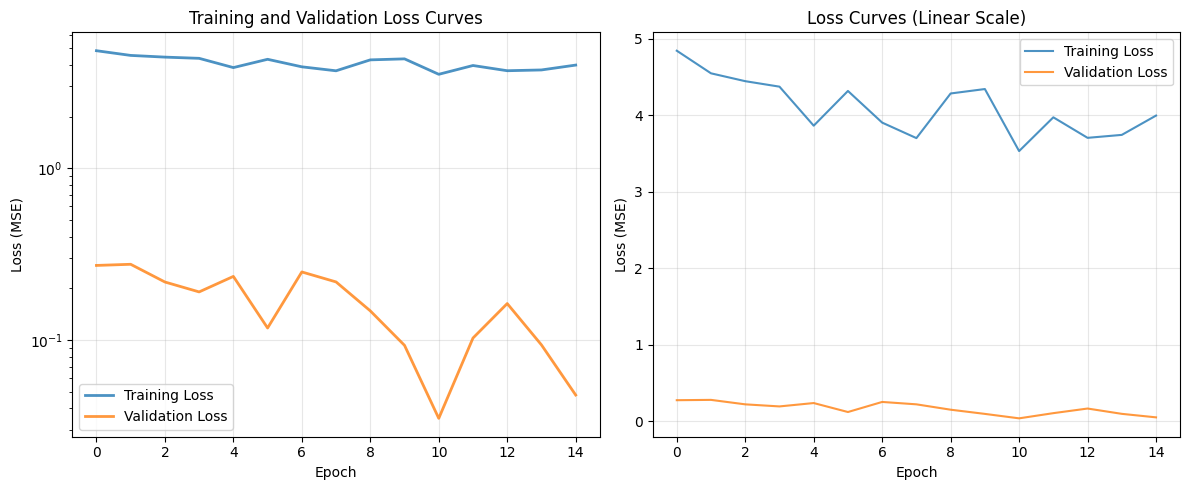

Test Loss: 11.080487


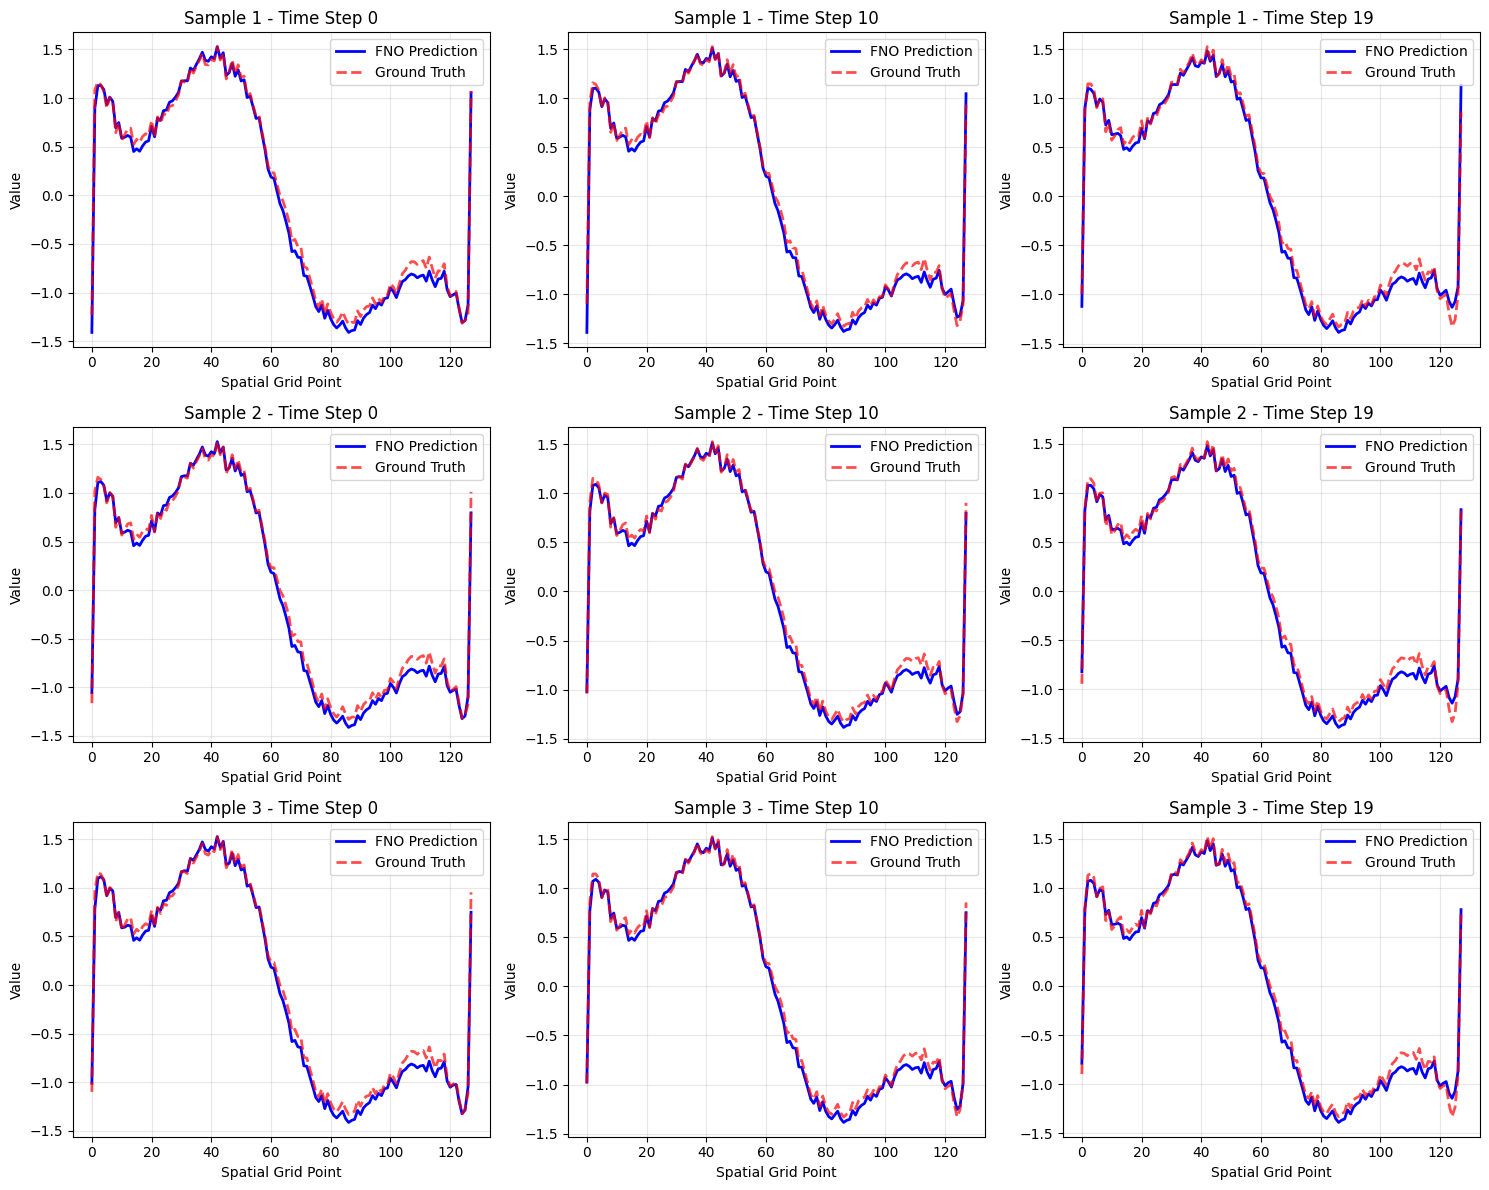

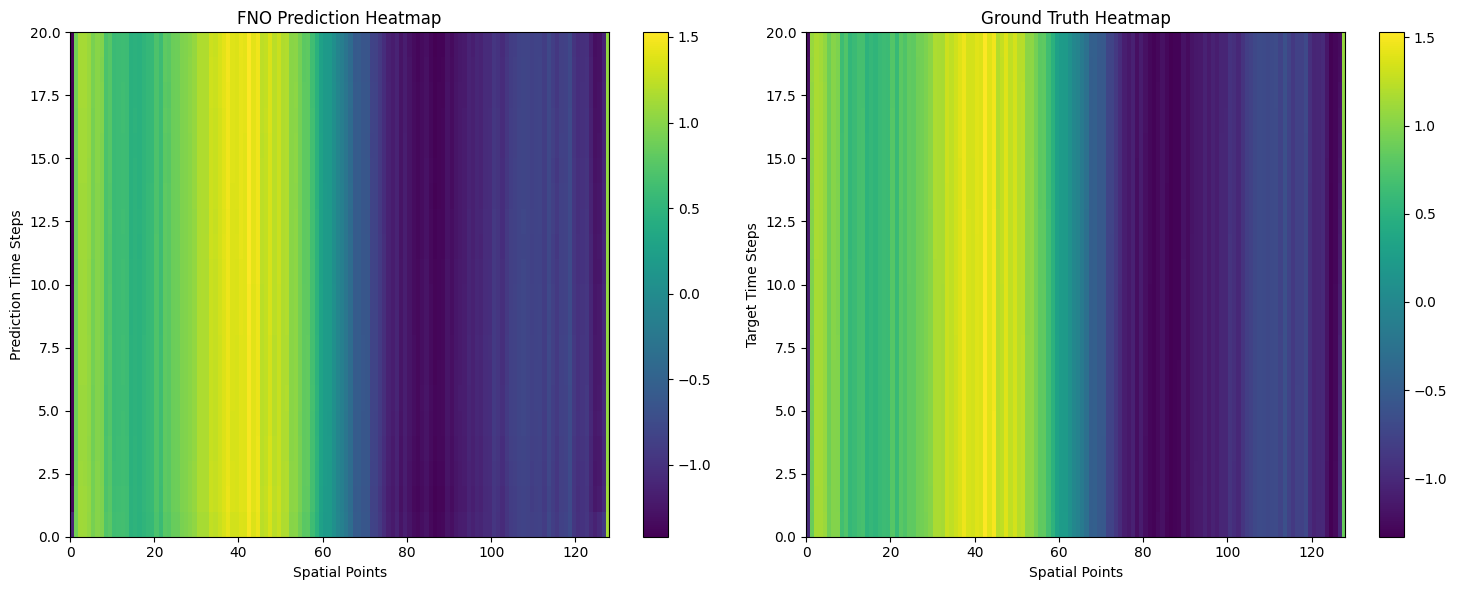

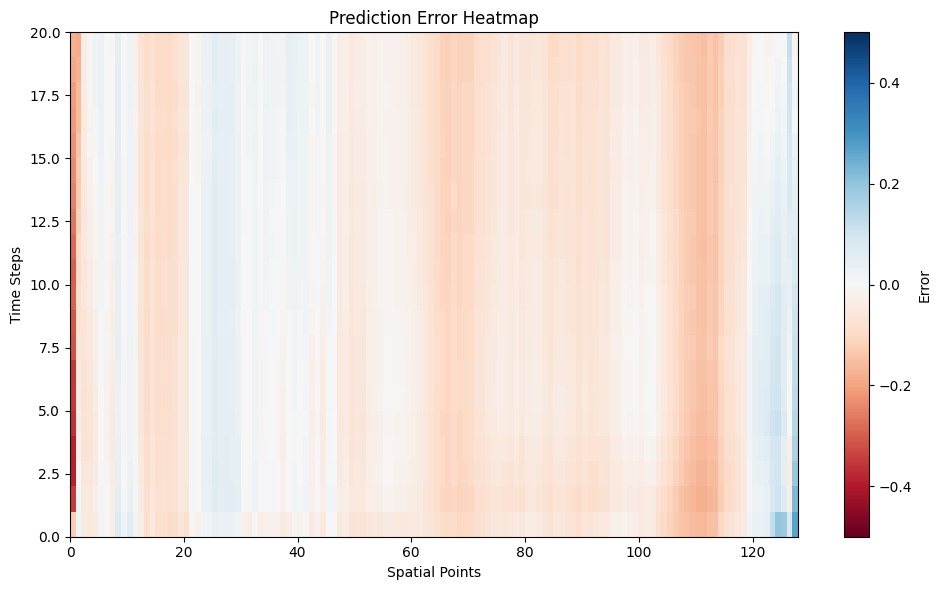


=== Model Performance Metrics ===
MSE: 11.346354
MAE: 0.060658
RMSE: 3.368435
Relative Error: 33.1899%
R² Score: 0.3819

=== Single Sample Prediction Example ===


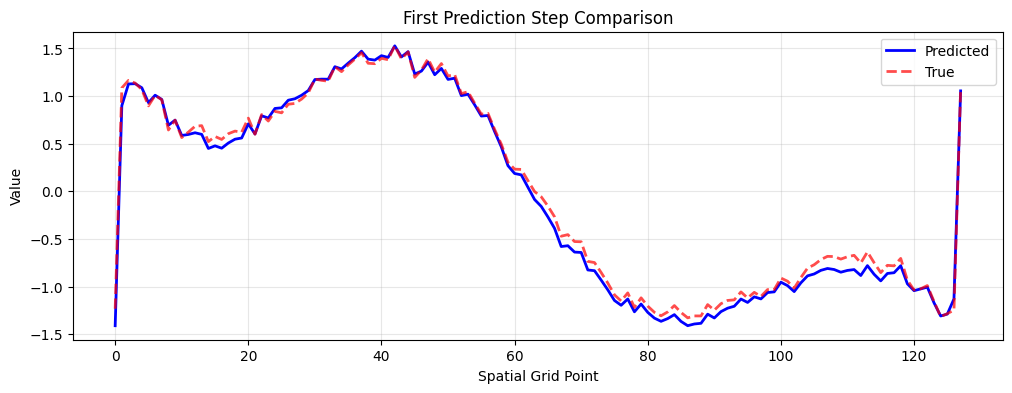


✅ FNO 1D Time Series Prediction Complete!
Model successfully predicted 20 future time steps from 10 input steps


In [ ]:

# Cell 10: Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(train_losses, label='Training Loss', alpha=0.8, linewidth=2)
plt.semilogy(val_losses, label='Validation Loss', alpha=0.8, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curves (Linear Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cell 11: Evaluate on test set
model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        output = model(batch_x)
        loss = criterion(output, batch_y)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.6f}")

# Cell 12: Visualize predictions
def visualize_predictions(model, X_test, y_test, num_samples=3):
    """Visualize FNO predictions vs ground truth"""
    model.eval()
    with torch.no_grad():
        predictions = model(X_test[:num_samples])

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # Plot multiple prediction steps
        time_indices = [0, prediction_steps//2, prediction_steps-1]

        for j, t_idx in enumerate(time_indices):
            pred = predictions[i, :, t_idx].cpu().numpy()
            truth = y_test[i, :, t_idx].cpu().numpy()

            axes[i, j].plot(pred, 'b-', label='FNO Prediction', linewidth=2)
            axes[i, j].plot(truth, 'r--', label='Ground Truth', linewidth=2, alpha=0.7)
            axes[i, j].set_title(f'Sample {i+1} - Time Step {t_idx}')
            axes[i, j].set_xlabel('Spatial Grid Point')
            axes[i, j].set_ylabel('Value')
            axes[i, j].legend()
            axes[i, j].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_predictions(model, X_test, y_test, num_samples=3)

# Cell 13: Full time series prediction visualization
def visualize_full_prediction(model, X_sample, y_sample, sample_idx=0):
    """Visualize full prediction sequence for one sample"""
    model.eval()
    with torch.no_grad():
        full_prediction = model(X_sample[sample_idx:sample_idx+1])

    pred_seq = full_prediction[0].cpu().numpy()  # (grid_points, prediction_steps)
    truth_seq = y_sample[sample_idx].cpu().numpy()

    # Create time and space mesh
    time_steps = np.arange(prediction_steps)
    spatial_points = np.arange(pred_seq.shape[0])

    # Plot heatmaps
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Prediction heatmap
    im1 = ax1.imshow(pred_seq.T, aspect='auto', cmap='viridis',
                     extent=[0, pred_seq.shape[0], 0, prediction_steps])
    ax1.set_title('FNO Prediction Heatmap')
    ax1.set_xlabel('Spatial Points')
    ax1.set_ylabel('Prediction Time Steps')
    plt.colorbar(im1, ax=ax1)

    # Ground truth heatmap
    im2 = ax2.imshow(truth_seq.T, aspect='auto', cmap='viridis',
                     extent=[0, truth_seq.shape[0], 0, prediction_steps])
    ax2.set_title('Ground Truth Heatmap')
    ax2.set_xlabel('Spatial Points')
    ax2.set_ylabel('Target Time Steps')
    plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    plt.show()

    # Plot error heatmap
    error = pred_seq - truth_seq
    plt.figure(figsize=(10, 6))
    im3 = plt.imshow(error.T, aspect='auto', cmap='RdBu',
                     extent=[0, pred_seq.shape[0], 0, prediction_steps], vmin=-0.5, vmax=0.5)
    plt.title('Prediction Error Heatmap')
    plt.xlabel('Spatial Points')
    plt.ylabel('Time Steps')
    plt.colorbar(im3, label='Error')
    plt.tight_layout()
    plt.show()

# Visualize for a test sample
visualize_full_prediction(model, X_test, y_test, sample_idx=0)

# Cell 14: Calculate additional metrics
def calculate_metrics(model, test_loader):
    """Calculate additional performance metrics"""
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds = model(batch_x)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Calculate metrics
    mse = np.mean((all_preds - all_targets) ** 2)
    mae = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(mse)

    # Relative error
    relative_error = np.mean(np.abs(all_preds - all_targets) / (np.abs(all_targets) + 1e-8))

    # R² score
    ss_res = np.sum((all_preds - all_targets) ** 2)
    ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-8))

    print("\n=== Model Performance Metrics ===")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Relative Error: {relative_error:.4%}")
    print(f"R² Score: {r2:.4f}")

    return mse, mae, rmse, relative_error, r2

metrics = calculate_metrics(model, test_loader)

# Cell 15: Example prediction for a single sample
print("\n=== Single Sample Prediction Example ===")
model.eval()
test_sample = X_test[0:1]
true_output = y_test[0]

with torch.no_grad():
    pred_output = model(test_sample)

pred_output = pred_output[0].cpu().numpy()
true_output = true_output.cpu().numpy()

# Plot the first prediction step
plt.figure(figsize=(12, 4))
plt.plot(pred_output[:, 0], 'b-', label='Predicted', linewidth=2)
plt.plot(true_output[:, 0], 'r--', label='True', linewidth=2, alpha=0.7)
plt.xlabel('Spatial Grid Point')
plt.ylabel('Value')
plt.title('First Prediction Step Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ FNO 1D Time Series Prediction Complete!")
print(f"Model successfully predicted {prediction_steps} future time steps from {input_steps} input steps")